In [1]:
import numpy as np
from matplotlib import pyplot as plt
import qutip as qt
from scipy.integrate import quad
from scipy.linalg import eigh
from scipy import interpolate as interp
from mpmath import polylog

from datataking import search_datadict_miyamura
from scipy import interpolate
from analysis import WaveformAnalysis, WaveformAnalysisMulti, fourier_tr_padding, lowpass, start_stop#, probe_resonator_fit

c:\Users\qipe\qutip_simulation\codes\analysis.py:620: SyntaxWarning: invalid escape sequence '\o'
  ax.set_xlabel('F0g1 frequency $\omega$ (GHz)')
c:\Users\qipe\qutip_simulation\codes\analysis.py:621: SyntaxWarning: invalid escape sequence '\G'
  ax.set_ylabel('$\Gamma_f $ /2$\pi$ (MHz)')
c:\Users\qipe\qutip_simulation\codes\analysis.py:624: SyntaxWarning: invalid escape sequence '\O'
  ax2.set_xlabel('$\Omega$')
c:\Users\qipe\qutip_simulation\codes\analysis.py:668: SyntaxWarning: invalid escape sequence '\G'
  ax.set_ylabel('$\Gamma_{\mathrm{f}}$ (MHz)')
c:\Users\qipe\qutip_simulation\codes\analysis.py:674: SyntaxWarning: invalid escape sequence '\G'
  ax2.set_xlabel('$\Gamma_{\mathrm{f}}$ (GHz)')
c:\Users\qipe\qutip_simulation\codes\analysis.py:704: SyntaxWarning: invalid escape sequence '\G'
  ax.set_ylabel('$\Gamma_{\mathrm{ph}}$')


In [2]:
cd = "CDY168"
data_path = f"C:\\Users\\qipe\\qutip_simulation\\codes\\data\\{cd}"
readout_lo_freq = 9.5

In [3]:
name_dict = dict(
    # data1 = dict(amp=0.1, date="2024-10-13", acquire_time="151503", params=dict(fit_start=400, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False)), 
    # data2 = dict(amp=0.15, date="2024-09-21", acquire_time="000452", params=dict(fit_start=100, fp=0.01, fs=0.05, gpass=1, gstop=90)), 
    data2 = dict(amp=0.2, date="2024-10-13", acquire_time="163259", params=dict(fit_start=300, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False)), 
    # data4 = dict(amp=0.25, date="2024-09-21", acquire_time="024338", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data5 = dict(amp=0.3, date="2024-10-04", acquire_time="030703", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data6 = dict(amp=0.35, date="2024-09-21", acquire_time="035001", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    data4 = dict(amp=0.4, date="2024-10-13", acquire_time="175059", params=dict(fit_start=240, fp=0.02, fs=0.05, gpass=1, gstop=90, plot=False)), 
    # data8 = dict(amp=0.45, date="2024-09-21", acquire_time="045614", params=dict(fit_start=20, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data9 = dict(amp=0.5, date="2024-10-04", acquire_time="041437", params=dict(fit_start=20, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data10 = dict(amp=0.55, date="2024-09-21", acquire_time="191718", params=dict(fit_start=20, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    data6 = dict(amp=0.6, date="2024-10-13", acquire_time="182305", params=dict(fit_start=100, fp=0.02, fs=0.05, gpass=1, gstop=90, plot=False)), 
    # data12 = dict(amp=0.7, date="2024-10-04", acquire_time="051354", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    data8 = dict(amp=0.8, date="2024-10-13", acquire_time="185235", params=dict(fit_start=140, fp=0.02, fs=0.05, gpass=1, gstop=90, plot=True, skip=[21, 22])), 
    # data9 = dict(amp=0.9, date="2024-10-13", acquire_time="192134", params=dict(fit_start=150, fp=0.02, fs=0.05, gpass=1, gstop=90, plot=True, skip=[])), 
    data10 = dict(amp=1.0, date="2024-10-13", acquire_time="195005", params=dict(fit_start=100, fp=0.02, fs=0.05, gpass=1, gstop=90, plot=False,skip=[23, 25])), 
    # data11 = dict(amp=1.1, date="2024-10-13", acquire_time="201835", params=dict(fit_start=100, fp=0.02, fs=0.05, gpass=1, gstop=90, plot=False, skip=[22, 23, 24, 25])), 

)

0.2 2024-10-13 163259
0.4 2024-10-13 175059
0.6 2024-10-13 182305
0.8 2024-10-13 185235
1.0 2024-10-13 195005


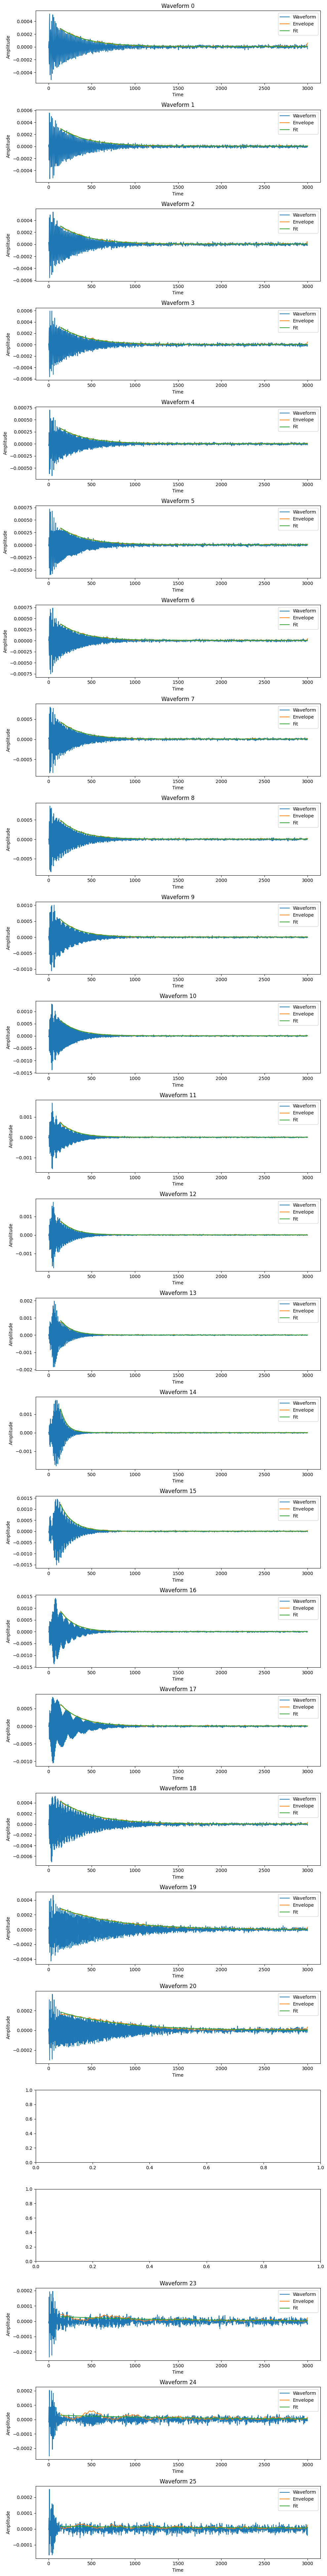

In [4]:
dataobj = WaveformAnalysisMulti(name_dict, data_path)
dataobj.generate_results(readout_lo_freq)

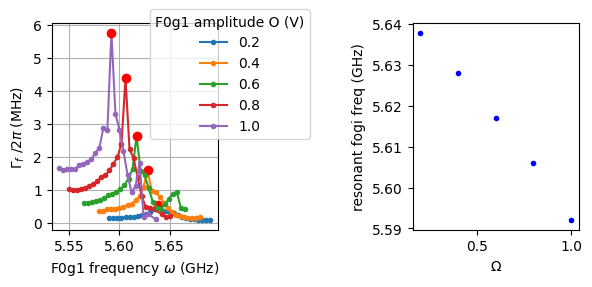

In [5]:
form = "sech_0"
const = 2.5e-3 * 2 * np.pi
duration = 1000
target_freq = 9.35

# plot decay rates
fogi_amps, max_decay_freq = dataobj.plot_decayrates()
resonant_fogi_freq = np.array(max_decay_freq) * 1e9

<>:2: SyntaxWarning: invalid escape sequence '\O'
<>:2: SyntaxWarning: invalid escape sequence '\O'
C:\Users\qipe\AppData\Local\Temp\ipykernel_6944\51486952.py:2: SyntaxWarning: invalid escape sequence '\O'
  plt.xlabel('fogi amplitude $\Omega$')


Text(0, 0.5, 'resonant fogi freq (GHz)')

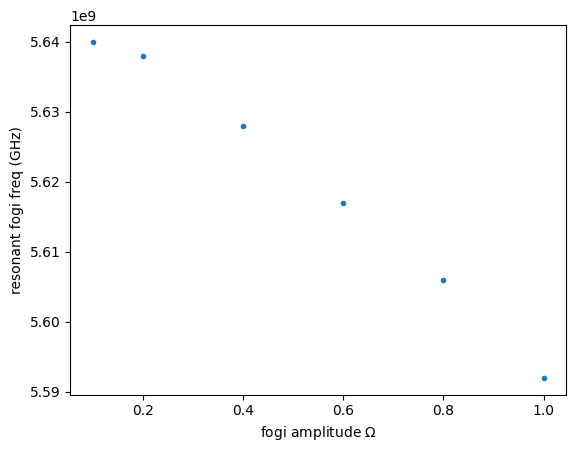

In [20]:
plt.plot(fogi_amps, resonant_fogi_freq, '.')
plt.xlabel('fogi amplitude $\Omega$')
plt.ylabel('resonant fogi freq (GHz)')

Fitted c: 3648686865.548438
Fitted omega_fg: 35426186983.85926
-7323920749862.12


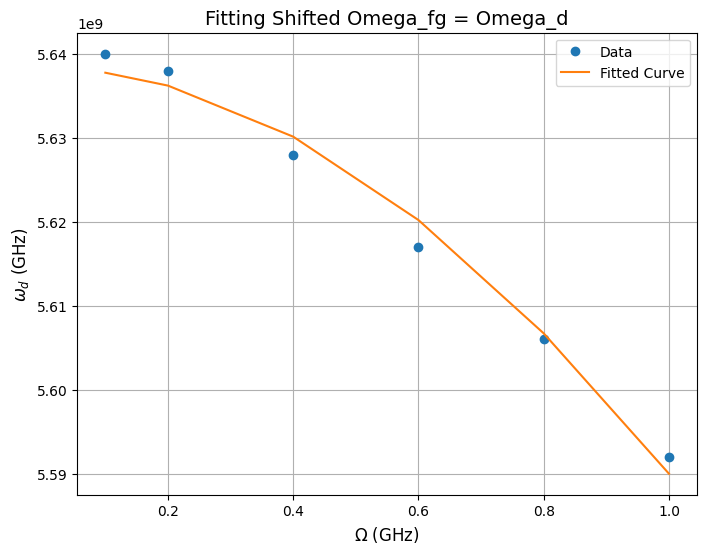

In [21]:
from scipy.optimize import fsolve
from scipy.optimize import curve_fit

omega_q = 7.699e9 * 2 * np.pi
alpha = -0.372e9 * 2 * np.pi

def shifted_omega_fg_fit(Omega, c, omega_fg):
    def calc_omega_d(Omega, c, omega_fg):
        def equation(omega_d):
            delta_qd = omega_q - omega_d
            numer = alpha * (2 * delta_qd + alpha) * (c * Omega)**2
            denom = 2 * delta_qd * (delta_qd + alpha) * (delta_qd + 2 * alpha)
            return omega_fg + numer / denom - omega_d

        omega_d_initial_guess = omega_fg
        return fsolve(equation, omega_d_initial_guess)[0]

    return np.array([calc_omega_d(om, c, omega_fg) for om in Omega])


initial_guess = [5e9, 5.64e9*2*np.pi]
popt, pcov = curve_fit(
    lambda Omega, c, omega_fg: shifted_omega_fg_fit(Omega, c, omega_fg),
    fogi_amps,
    resonant_fogi_freq*2*np.pi,
    p0=initial_guess
)

fitted_c, fitted_omega_fg = popt
print(f"Fitted c: {fitted_c}")
print(f"Fitted omega_fg: {fitted_omega_fg}")

print(alpha * (2 * (omega_q - resonant_fogi_freq[0]*2*np.pi) + alpha) * (fitted_c * fogi_amps[0])**2*(1e-6)**4)


initial_fitted_values = shifted_omega_fg_fit(fogi_amps, initial_guess[0], initial_guess[1])
fitted_omega_d_values = shifted_omega_fg_fit(fogi_amps, fitted_c, fitted_omega_fg)

plt.figure(figsize=(8, 6))
plt.plot(fogi_amps, resonant_fogi_freq, 'o', label="Data")
# plt.plot(fogi_amps, initial_fitted_values / (2 * np.pi), '--', label="Initial Fit") 
plt.plot(fogi_amps, fitted_omega_d_values/(2*np.pi), '-', label="Fitted Curve")
plt.xlabel(r"$\Omega$ (GHz)", fontsize=12)
plt.ylabel(r"$\omega_d$ (GHz)", fontsize=12)
plt.title("Fitting Shifted Omega_fg = Omega_d", fontsize=14)
plt.grid()
plt.legend()
plt.show()


qutip simulation

In [9]:
from qutip import *

In [10]:
Nqu=4;
Nres=3;
Nfil=3;
## define qubit 
omegaq=2*np.pi*7699;
aharmon=-2*np.pi*372;

qubitobj=basis(Nqu,2);
bqub=destroy(Nqu);
bqubd=create(Nqu);


## define resonator
omegares_g = 2*np.pi*9377;
omegares_e = 2*np.pi*9371.2;
omegares=(omegares_g + omegares_e)/2;
Jcavfil=2*np.pi*46;

cavobj=basis(Nres);
acav=destroy(Nres);
acavd=create(Nres);
## define filter
omegafil_g = 2*np.pi*9395.3;
omegafil_e = 2*np.pi*9394.7;
omegafil=(omegafil_g + omegafil_e)/2;
kappa=2*np.pi*95
filterobj=basis(Nfil);
fcav=destroy(Nfil);
fcavd=create(Nfil);

##### 
c_ops=[];
c_ops.append(np.sqrt(kappa)*tensor(qeye(Nqu),acav))


## qubit-resonator coupling strength
omega_rotate=2*np.pi*6000

In [13]:
def omega_l(omega_res, omega_fil):
    delta_rfil = omega_res - omega_fil
    return (omega_res + omega_fil)/2 - np.real(np.sqrt((delta_rfil-1j*kappa/2)**2 + 4*Jcavfil**2))/2
def omega_h(omega_res, omega_fil):
    delta_rfil = omega_res - omega_fil
    return (omega_res + omega_fil)/2 + np.real(np.sqrt((delta_rfil-1j*kappa/2)**2 + 4*Jcavfil**2))/2
print(omega_l(omegares, omegafil)/2/np.pi, omega_h(omegares, omegafil)/2/np.pi)

def kappa_l(omega_res, omega_fil):
    delta_rfil = omegares_g - omega_fil
    return kappa/2 + np.imag(np.sqrt((delta_rfil-1j*kappa/2)**2 + 4*Jcavfil**2))
def kappa_h(omega_res, omega_fil):
    delta_rfil = omegares_g - omega_fil
    return kappa/2 - np.imag(np.sqrt((delta_rfil-1j*kappa/2)**2 + 4*Jcavfil**2))
print(kappa_l(omegares, omegafil)/2/np.pi, kappa_h(omegares, omegafil)/2/np.pi)

chi_l = (omega_l(omegares_e, omegafil_e) - omega_l(omegares_g, omegafil_g))/2
chi_h = (omega_h(omegares_e, omegafil_e) - omega_h(omegares_g, omegafil_g))/2
print(chi_l/2/np.pi, chi_h/2/np.pi)

g_l = np.sqrt(chi_l*(omegaq - omega_l(omegares, omegafil))*(omegaq - omega_l(omegares, omegafil)+aharmon)/aharmon)
g_h = np.sqrt(chi_h*(omegaq - omega_h(omegares, omegafil))*(omegaq - omega_h(omegares, omegafil)+aharmon)/aharmon)
print(g_l/2/np.pi, g_h/2/np.pi)

c_ops_fil=[];
c_ops_fil.append(np.sqrt(kappa_l(omegares, omegafil))*tensor(qeye(Nqu),acav,qeye(Nfil)))
c_ops_fil.append(np.sqrt(kappa_h(omegares, omegafil))*tensor(qeye(Nqu),qeye(Nres),fcav))

9343.350140256101 9425.749859743899
57.99114182817304 37.008858171826965
-2.029673591656498 -1.1703264083433758
134.49983617264243 106.77684572702067


In [17]:
H0_fil=(omegaq-omega_rotate)*tensor(bqubd*bqub,qeye(Nres),qeye(Nfil))+aharmon/2*tensor(bqubd*bqubd*bqub*bqub,qeye(Nres),qeye(Nfil))\
+(omega_l(omegares, omegafil)-omega_rotate)*tensor(qeye(Nqu),acavd*acav,qeye(Nfil))+g_l*(tensor(bqub,acavd,qeye(Nfil))+tensor(bqubd,acav,qeye(Nfil)))\
+(omega_h(omegares, omegafil)-omega_rotate)*tensor(qeye(Nqu),qeye(Nres),fcavd*fcav)+g_h*(tensor(bqub,qeye(Nres),fcavd)+tensor(bqubd,qeye(Nres),fcav))

def H1_coeff_sq_f0g1_pulse_ani(t, args):
    return args['Omegagf']*np.sin(args['omegadrive_f0g1']*t)*np.exp(-1j*omega_rotate*t)

def H1_coeff_sq_f0g1_pulse_crea(t, args):
    return args['Omegagf']*np.sin(args['omegadrive_f0g1']*t)*np.exp(1j*omega_rotate*t)

H1_anni_fil= tensor(bqub,qeye(Nres),qeye(Nfil))
H1_crea_fil= tensor(bqubd,qeye(Nres),qeye(Nfil))

H_f0g1_fil = [ H0_fil,
              [H1_anni_fil, H1_coeff_sq_f0g1_pulse_ani],
              [H1_crea_fil, H1_coeff_sq_f0g1_pulse_crea]
            ]

In [18]:
eigsystem_fil=H0_fil.eigenstates()
f00_fil=tensor(basis(Nqu,2),cavobj,filterobj);
e00_fil=tensor(basis(Nqu,1),cavobj,filterobj);
g00_fil=tensor(basis(Nqu),cavobj,filterobj);

g10_fil=tensor(basis(Nqu),basis(Nres,1), filterobj);
e10_fil=tensor(basis(Nqu,1),basis(Nres,1), filterobj);

g01_fil=tensor(basis(Nqu),cavobj,basis(Nfil,1));
e01_fil=tensor(basis(Nqu,1),cavobj,basis(Nfil,1));

overlaplistf00_fil=[fidelity(f00_fil,eigsystem_fil[1][cc]) for cc in range(len(eigsystem_fil[0]))]
overlapliste00_fil=[fidelity(e00_fil,eigsystem_fil[1][cc]) for cc in range(len(eigsystem_fil[0]))]
overlaplistg00_fil=[fidelity(g00_fil,eigsystem_fil[1][cc]) for cc in range(len(eigsystem_fil[0]))]

overlaplistg10_fil=[fidelity(g10_fil,eigsystem_fil[1][cc]) for cc in range(len(eigsystem_fil[0]))]
overlapliste10_fil=[fidelity(e10_fil,eigsystem_fil[1][cc]) for cc in range(len(eigsystem_fil[0]))]

overlaplistg01_fil=[fidelity(g01_fil,eigsystem_fil[1][cc]) for cc in range(len(eigsystem_fil[0]))]
overlapliste01_fil=[fidelity(e01_fil,eigsystem_fil[1][cc]) for cc in range(len(eigsystem_fil[0]))]

maxindexf00_fil=overlaplistf00_fil.index(max(overlaplistf00_fil))
maxindexe00_fil=overlapliste00_fil.index(max(overlapliste00_fil))
maxindexg00_fil=overlaplistg00_fil.index(max(overlaplistg00_fil))
maxindexg10_fil=overlaplistg10_fil.index(max(overlaplistg10_fil))
maxindexe10_fil=overlapliste10_fil.index(max(overlapliste10_fil))
maxindexg01_fil=overlaplistg01_fil.index(max(overlaplistg01_fil))
maxindexe01_fil=overlapliste01_fil.index(max(overlapliste01_fil))

# omegaf0g1_fil=np.abs(eigsystem_fil[0][maxindexf00_fil]-eigsystem_fil[0][maxindexg01_fil])

initialstatef00_fil=eigsystem_fil[1][maxindexf00_fil]
initialstatee00_fil=eigsystem_fil[1][maxindexe00_fil]
initialstateg00_fil=g00_fil

initialstateg10_fil=eigsystem_fil[1][maxindexg10_fil]
initialstateg01_fil=eigsystem_fil[1][maxindexg01_fil]

In [22]:
Tf=3
t=np.linspace(0,Tf,3001)
testinitialstate_fil=(initialstatef00_fil+initialstateg00_fil).unit()
options = qt.Options(store_states=True)

gstate_fil=tensor(ket2dm(basis(Nqu)),qeye(Nres),qeye(Nfil))
estate_fil=tensor(ket2dm(basis(Nqu,1)),qeye(Nres),qeye(Nfil))
fstate_fil=tensor(ket2dm(basis(Nqu,2)),qeye(Nres),qeye(Nfil))
hstate_fil=tensor(ket2dm(basis(Nqu,3)),qeye(Nres),qeye(Nfil))

omegadrive_f0g1_dict = {
    # 0.2: np.array([5.58, 5.605, 5.63, 5.655, 5.68]) *1e3* 2 * np.pi,
    # 0.4: np.array([5.575, 5.6, 5.625, 5.65, 5.675])*1e3*  2 * np.pi,
    # 0.6: np.array([5.56, 5.585, 5.6, 5.61, 5.62, 5.635, 5.66])*1e3*  2 * np.pi,
    0.8: np.array([5.525, 5.55, 5.575, 5.59, 5.6, 5.61, 5.625, 5.65, 5.675]) *1e3* 2 * np.pi,
    # 1.0: np.array([5.54, 5.565, 5.59, 5.615, 5.64]) *1e3* 2 * np.pi,
}
# Omegas = np.array([0.2, 0.4, 0.6, 0.8, 1.0])
Omegas = np.array([0.8])

results = []
for Omega in Omegas:
    output_decay_f0g1_fils = []
    drive_freqs = omegadrive_f0g1_dict[Omega]  
    for drive_freq in drive_freqs:
        args = {
            'Omegagf': fitted_c*1e-6*Omega,
            'omegadrive_f0g1': drive_freq
        }

        output_decay_f0g1_fil = mesolve(H_f0g1_fil,testinitialstate_fil, t, c_ops_fil,e_ops=[], options=options, progress_bar=True,args=args)
        output_decay_f0g1_fils.append(output_decay_f0g1_fil)
        print(f'Omegagf={Omega}, omegadrive_f0g1={drive_freq/(2*np.pi)} finished')
    results.append(output_decay_f0g1_fils)
    

c:\Users\qipe\qutip_simulation\.venv\Lib\site-packages\qutip\solver\solver_base.py:460: FutureWarning: "progress_bar" is now included in options:
 Use `options={"progress_bar": False / True / "tqdm" / "enhanced"}`
  warnings.warn(


10.0%. Run time:  13.68s. Est. time left: 00:00:02:03
20.0%. Run time:  27.60s. Est. time left: 00:00:01:50
30.0%. Run time:  41.33s. Est. time left: 00:00:01:36
40.0%. Run time:  54.94s. Est. time left: 00:00:01:22
50.0%. Run time:  69.08s. Est. time left: 00:00:01:09
60.0%. Run time:  82.86s. Est. time left: 00:00:00:55
70.0%. Run time:  96.18s. Est. time left: 00:00:00:41
80.0%. Run time: 109.95s. Est. time left: 00:00:00:27
90.0%. Run time: 123.96s. Est. time left: 00:00:00:13
100.0%. Run time: 138.44s. Est. time left: 00:00:00:00
Total run time: 138.44s
Omegagf=0.8, omegadrive_f0g1=5525.0 finished
10.0%. Run time:  14.11s. Est. time left: 00:00:02:06
20.0%. Run time:  28.92s. Est. time left: 00:00:01:55
30.0%. Run time:  42.42s. Est. time left: 00:00:01:38
40.0%. Run time:  55.91s. Est. time left: 00:00:01:23
50.0%. Run time:  69.53s. Est. time left: 00:00:01:09
60.0%. Run time:  83.77s. Est. time left: 00:00:00:55
70.0%. Run time:  97.79s. Est. time left: 00:00:00:41
80.0%. Run t

In [23]:
c_res = qt.tensor([qt.identity(Nqu), qt.destroy(Nres), qt.identity(Nfil)])
cd_res = c_res.dag()
f_res = qt.tensor([qt.identity(Nqu), qt.identity(Nres), qt.destroy(Nfil)])
fd_res = f_res.dag()

In [24]:
from analysis import decay
import lmfit as lmf

def guess_params_decay(data, t):
    off_ini = np.mean(data[-5:])#data[-1]
    moving_average = np.convolve(data, np.ones(25)/25, mode="valid")
    A_ini = moving_average[0]#np.sign(data[0]-data[-1])*(max(data) - min(data))
    par_ini = {
        'gamma': abs((moving_average[0]-moving_average[5])/(t[0]-t[5]))/A_ini,#-(data[0]-data[2])/(t[0]-t[2]) ,
        'A': A_ini,'off': off_ini
    }
    par_max = {'gamma': 1e3,'A': 2*A_ini,'off': 5*np.abs(off_ini)}
    par_min = {'gamma': 0,'A': 0.5*A_ini,'off': -5*np.abs(off_ini)}
    par_vary = {'gamma': True,'A': True,'off': True,}
    return par_ini,par_max,par_min,par_vary

def decay_fit(data, t):
    decay_model = lmf.Model(decay)
    params_decay = decay_model.make_params()
    decay_par_ini,decay_par_max,decay_par_min,decay_par_vary=guess_params_decay(data,t)
    for name in params_decay:
        params_decay[name].set(
            value=decay_par_ini[name],  # 初期値
            min=decay_par_min[name],  # 下限値
            max=decay_par_max[name],  # 上限値
            vary=decay_par_vary[name] # パラメータを動かすかどうか
        )
    result=decay_model.fit(data, t=t, params=params_decay, method='leastsq')
    delm = result.eval_uncertainty(sigma=1)
    return result

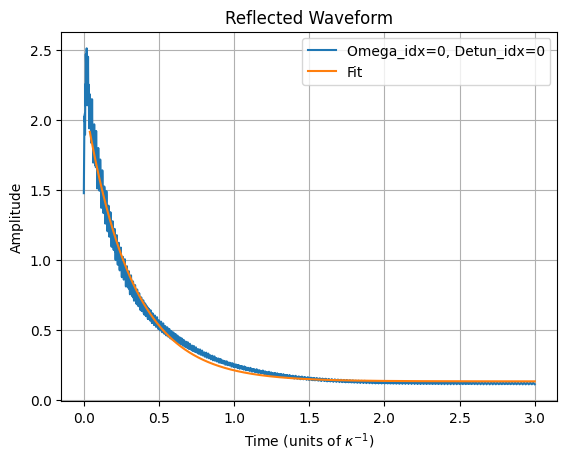

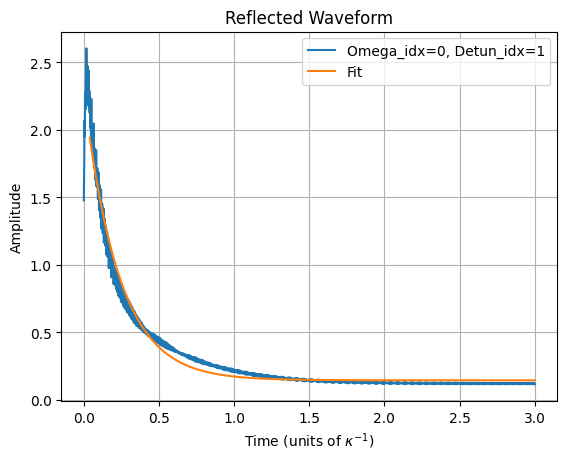

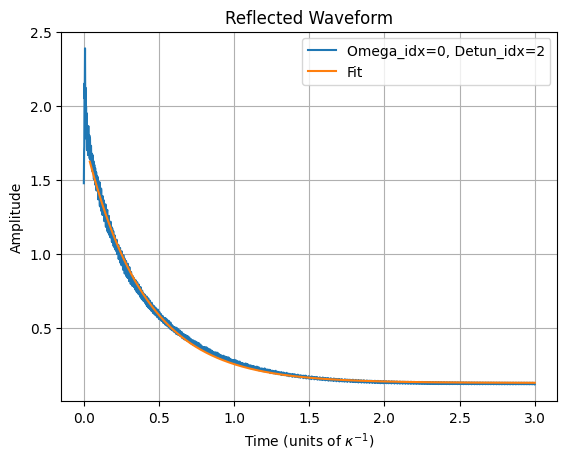

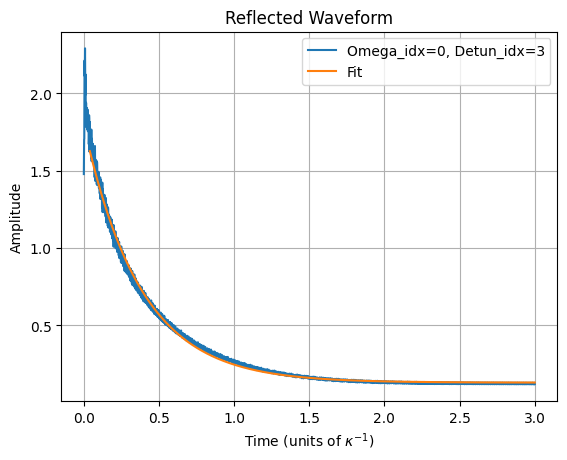

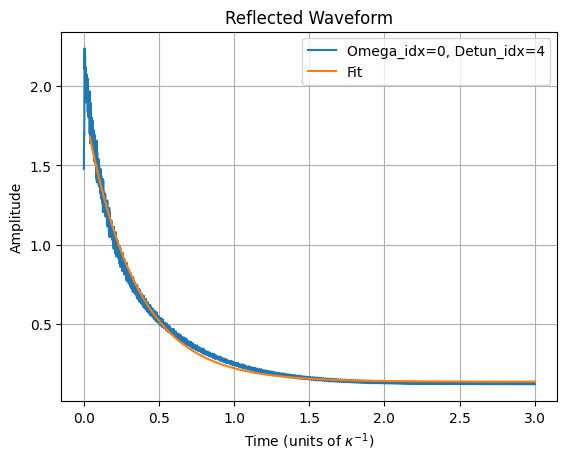

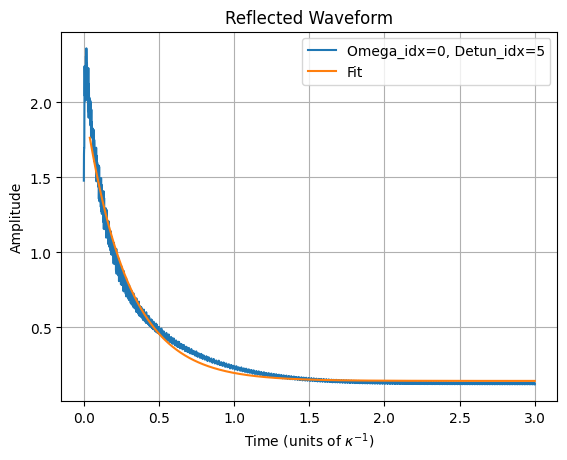

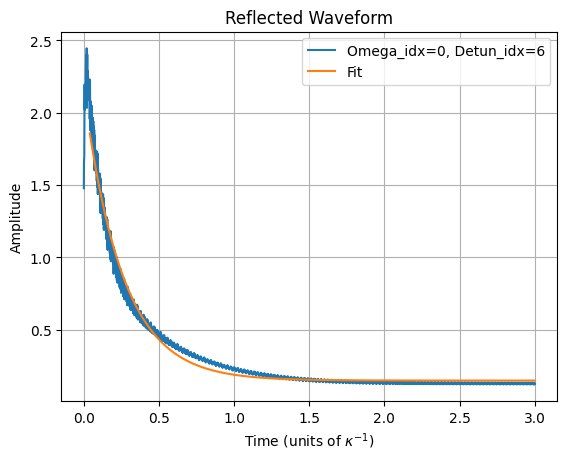

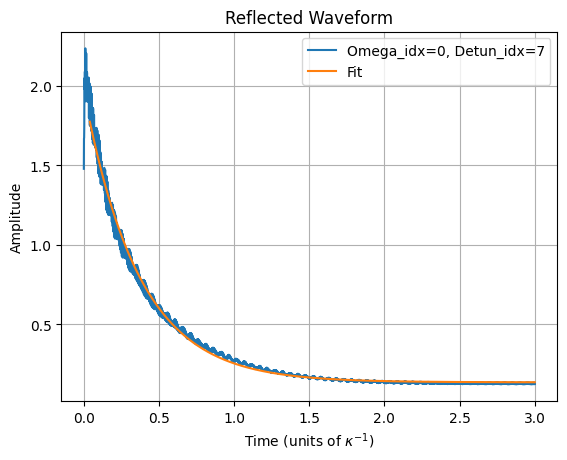

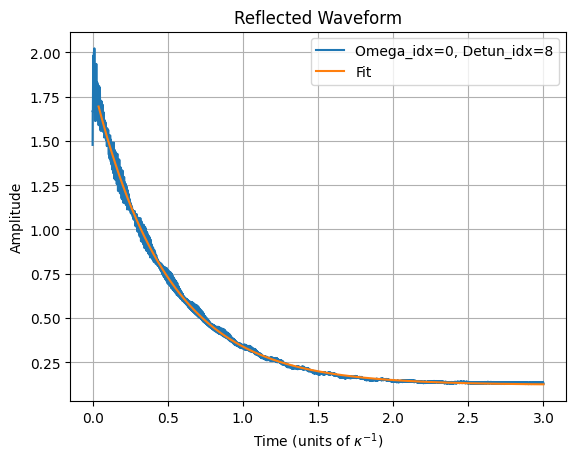

In [25]:
skip_data = 40
tmfs_by_omega = []
tmf_times_by_omega = []
decay_rates_by_omega = []
for omega_idx, omega_results in enumerate(results):
    tmfs_per_omega = []
    tmf_times_per_omega = [] 
    decay_rates_per_omega = []
    for detun_idx, output_decay_f0g1_fil in enumerate(omega_results):
        states = output_decay_f0g1_fil.states
        # Resonator operators
        c_s = qt.expect(c_res, states)
        cd_s = qt.expect(c_res.dag(), states)
        cdc_s = qt.expect(c_res.dag()*c_res, states)

        # Filter operators
        f_s = qt.expect(f_res, states)
        fd_s = qt.expect(f_res.dag(), states)
        fdf_s = qt.expect(qt.tensor(f_res.dag()*f_res), states)
        LdL = (
            kappa_l(omegares, omegafil)*cdc_s + kappa_h(omegares, omegafil)*fdf_s
            + np.sqrt(kappa_l(omegares, omegafil)*kappa_h(omegares, omegafil)) *  (cd_s*f_s + fd_s*c_s)
        )

        tmf_time = np.sqrt(LdL)
        tmf = np.abs(tmf_time)
        fit_result = decay_fit(tmf[skip_data:], t[skip_data:])

        fig, ax = plt.subplots()
        ax.plot(t, tmf, label=f"Omega_idx={omega_idx}, Detun_idx={detun_idx}")
        ax.plot(t[skip_data:], fit_result.best_fit, label="Fit")
        ax.legend()
        ax.grid()
        ax.set_title(f"Omega={Omegas[omega_idx]:.1f}, omega_d={omegadrive_f0g1_dict[Omegas[omega_idx]][detun_idx]/(2*np.pi):.1f} MHz")
        ax.set_title("Reflected Waveform")
        ax.set_xlabel(r"Time (units of $\kappa^{-1}$)")
        ax.set_ylabel("Amplitude")

        tmfs_per_omega.append(tmf)
        tmf_times_per_omega.append(tmf_time)
        decay_rates_per_omega.append(fit_result.params.valuesdict()["gamma"] /2/np.pi)
    tmfs_by_omega.append(tmfs_per_omega)
    tmf_times_by_omega.append(tmf_times_per_omega)
    decay_rates_by_omega.append(decay_rates_per_omega)

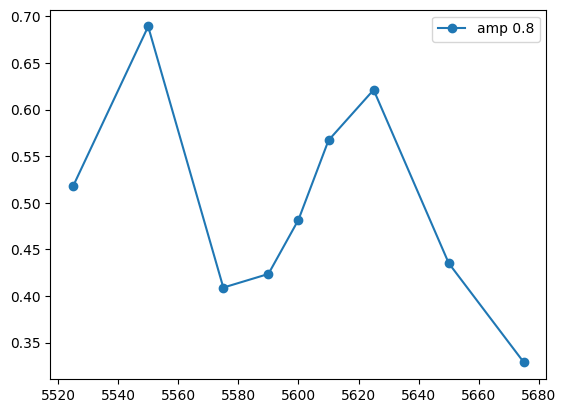

In [26]:
for i in range(1):
    plt.plot(omegadrive_f0g1_dict[Omegas[i]]/(2*np.pi), decay_rates_by_omega[i], 'o-', label=f"amp {Omegas[i]}")
    plt.legend()

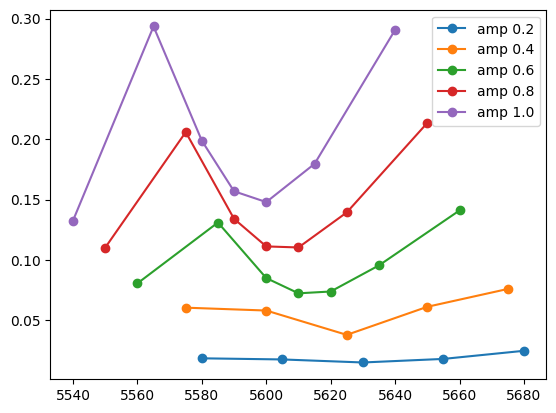

In [38]:
for i in range(5):
    plt.plot(omegadrive_f0g1_dict[Omegas[i]]/(2*np.pi), decay_rates_by_omega[i], 'o-', label=f"amp {Omegas[i]}")
    plt.legend()

IndexError: list index out of range

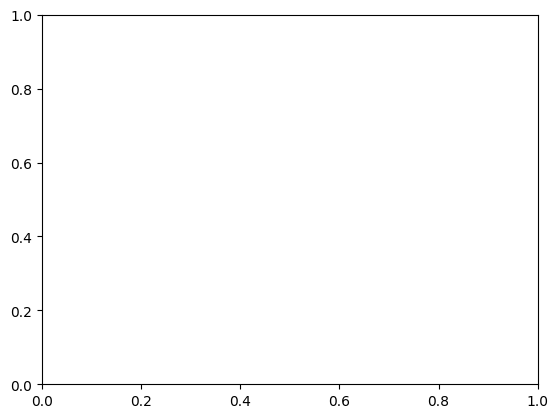

In [18]:
skip_data = 50
tmfs_by_omega = []
tmf_times_by_omega = []
decay_rates_by_omega = []
# `results` : results[Omega_index][detun_index]
for omega_idx, omega_results in enumerate(results):
    tmfs_per_omega = []
    tmf_times_per_omega = [] 
    decay_rates_per_omega = []
    for detun_idx, output_decay_f0g1_fil in enumerate(omega_results):
        fig, ax = plt.subplots()

        tmf_time = output_decay_f0g1_fil.expect[-1]
        tmf = np.abs(tmf_time)
        fit_result = decay_fit(tmf[skip_data:], t[skip_data:])

        ax.plot(t, tmf, label=f"Omega_idx={omega_idx}, Detun_idx={detun_idx}")
        ax.plot(t[skip_data:], fit_result.best_fit, label="Fit")
        ax.set_title(f"Omega={Omegas[omega_idx]:.1f}, omega_d={omegadrive_f0g1_dict[Omegas[omega_idx]][detun_idx]/(2*np.pi):.1f} MHz")
        ax.set_xlabel("Time")
        ax.set_ylabel("Amplitude")
        ax.legend()
        ax.grid()

        tmfs_per_omega.append(tmf)
        tmf_times_per_omega.append(tmf_time)
        decay_rates_per_omega.append(fit_result.params.valuesdict()["gamma"] /2/np.pi)

        plt.show()
    tmfs_by_omega.append(tmfs_per_omega)
    tmf_times_by_omega.append(tmf_times_per_omega)
    decay_rates_by_omega.append(decay_rates_per_omega)

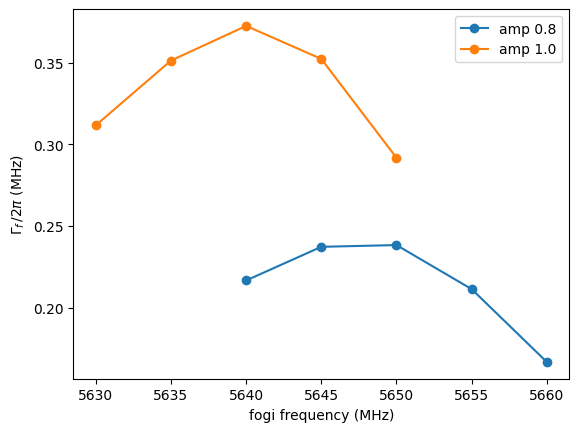

In [105]:
for i in range(2):
    plt.plot(omegadrive_f0g1_dict[Omegas[i]]/(2*np.pi), decay_rates_by_omega[i], 'o-', label=f"amp {Omegas[i]}")
    plt.xlabel("fogi frequency (MHz)")
    plt.ylabel(r"$\Gamma_f\, /2\pi$ (MHz)")
    plt.legend()

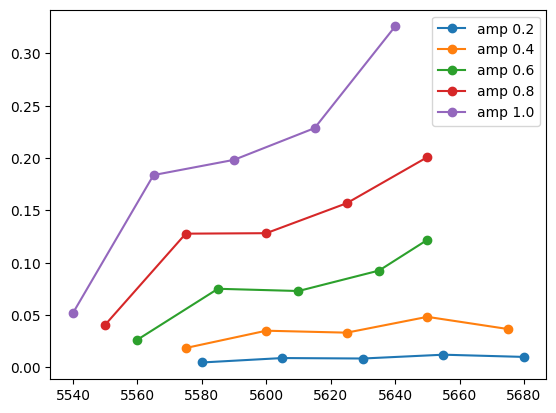

In [66]:
for i in range(5):
    plt.plot(omegadrive_f0g1_dict[Omegas[i]]/(2*np.pi), decay_rates_by_omega[i], 'o-', label=f"amp {Omegas[i]}")
    plt.legend()

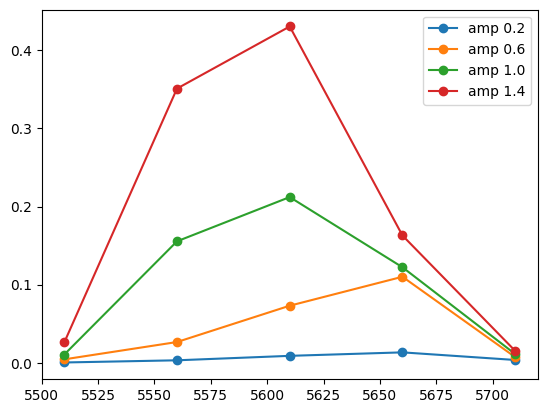

In [49]:
for i in range(4):
    plt.plot(5.61e3+ detuns/(2*np.pi), decay_rates_by_omega[i], 'o-', label=f"amp {Omegas[i]}")
    plt.legend()

NameError: name 'i' is not defined

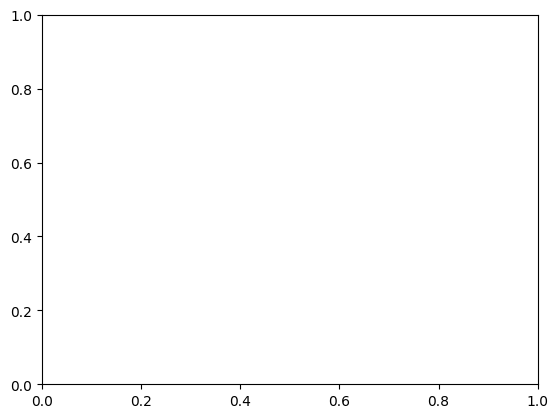

In [49]:
for omega_idx, omega_results in enumerate(results):

    for detun_idx, output_decay_f0g1_fil in enumerate(omega_results):
        fig, axes = plt.subplots()
        plt.plot(t,output_decay_f0g1_fils[i].expect[0],'r')
        plt.plot(t,output_decay_f0g1_fils[i].expect[1],'c')
        plt.plot(t,output_decay_f0g1_fils[i].expect[2],'b')
        plt.plot(t,output_decay_f0g1_fils[i].expect[3],'k')
        plt.xlabel('Time', fontsize=14)
        plt.ylabel('Expectation values', fontsize=14)
        plt.ylim(0, 1)
        plt.legend(("f0g1_g","f0g1_e","f0g1_f","f0g1_h"))